# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values
pairs = [('weight', 'displacement'), ('horsepower', 'mpg'), ('acceleration', 'mpg')]
results = []

for x, y in pairs:
    pearson_r, p_p = stats.pearsonr(mpg[x], mpg[y])
    spearman_r, p_s = stats.spearmanr(mpg[x], mpg[y])
    results.append({"Pair": f"{x} & {y}", "Pearson R": round(pearson_r, 4), "P-value (P)": f"{p_p:.4e}", 
                    "Spearman R": round(spearman_r, 4), 
                    "P-value (S)": f"{p_s:.4e}"})

results_df = pd.DataFrame(results)
print(results_df)

                    Pair  Pearson R  P-value (P)  Spearman R  P-value (S)
0  weight & displacement     0.9330  3.4891e-175      0.9456  2.4632e-192
1       horsepower & mpg    -0.7784   7.0320e-81     -0.8536  1.6194e-112
2     acceleration & mpg     0.4233   1.7786e-18      0.4415   3.9036e-20


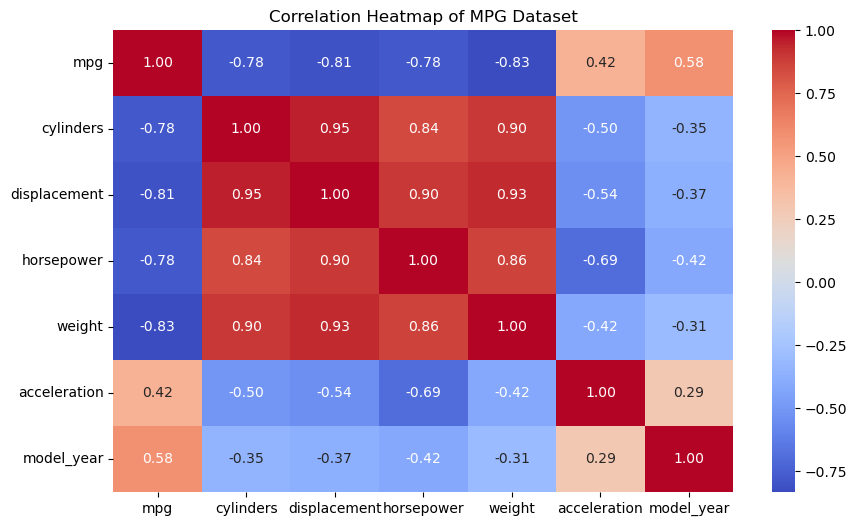

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
numeric_mpg = mpg.select_dtypes(include=[np.number])
sns.heatmap(numeric_mpg.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of MPG Dataset")
plt.show()

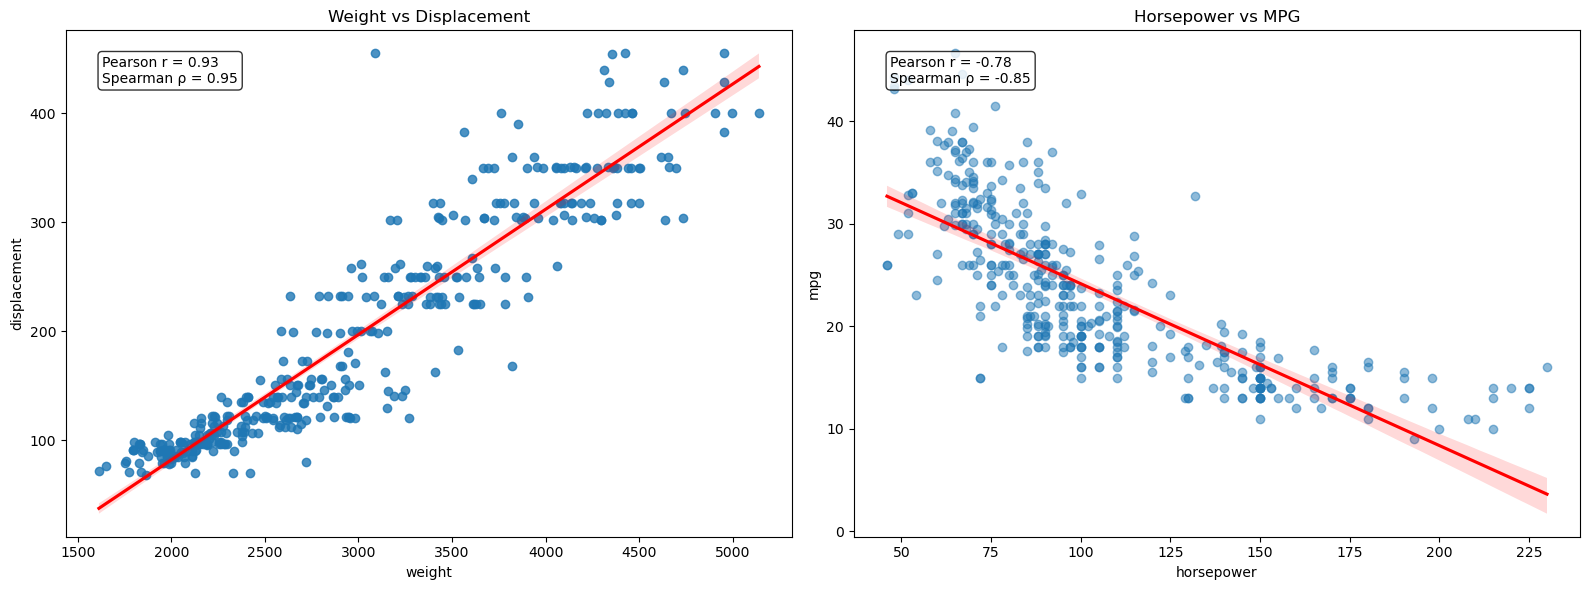

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


r1_p, _ = stats.pearsonr(mpg['weight'].dropna(), mpg['displacement'].dropna())
r1_s, _ = stats.spearmanr(mpg['weight'].dropna(), mpg['displacement'].dropna())

r2_p, _ = stats.pearsonr(mpg['horsepower'].dropna(), mpg['mpg'].dropna())
r2_s, _ = stats.spearmanr(mpg['horsepower'].dropna(), mpg['mpg'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Weight vs Displacement
sns.regplot(data=mpg, x='weight', y='displacement', ax=axes[0], line_kws={"color": "red"})
axes[0].set_title("Weight vs Displacement")

axes[0].text(0.05, 0.95, f"Pearson r = {r1_p:.2f}\nSpearman ρ = {r1_s:.2f}", 
             transform=axes[0].transAxes, verticalalignment='top', 
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Plot 2: Horsepower vs MPG
sns.regplot(data=mpg, x='horsepower', y='mpg', ax=axes[1], line_kws={"color": "red"}, scatter_kws={'alpha': 0.5})
axes[1].set_title("Horsepower vs MPG")

axes[1].text(0.05, 0.95, f"Pearson r = {r2_p:.2f}\nSpearman ρ = {r2_s:.2f}", 
             transform=axes[1].transAxes, verticalalignment='top', 
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

### Pearson vs. Spearman: Which to Use?


The choice between Pearson and Spearman correlation depends on the distribution of your data and the nature of the relationship between variables.

1. Pearson Correlation (r)
Best Use: When the relationship is linear and the variables follow a normal distribution. It measures how closely points fit a straight line.

Example from results: Weight vs. Displacement. In the scatter plot, the data points cluster tightly along a straight path. The Pearson coefficient is 0.9330, which captures this strong linear relationship perfectly.

2. Spearman Correlation (ρ)
Best Use: When the relationship is monotonic (moving in the same direction but not at a constant rate) or when the data contains outliers. It uses ranks rather than raw values, making it robust against non-linear curves.

Example from results: Horsepower vs. MPG. The scatter plot shows a distinct curve; as horsepower increases, MPG drops rapidly at first and then flattens out.

Pearson r: -0.7784

Spearman R: -0.8536

Conclusion: Because the Spearman coefficient is notably higher than the Pearson coefficient, it confirms that while the relationship is not perfectly linear, it is a very strong, consistent downward trend.

    ---
    ## Task 2 — Group Comparisons
    
    1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
    2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
    3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
    4. If significant, run Tukey's HSD and state which groups differ.

C:\Users\Vito\AppData\Local\Temp\ipykernel_10052\4282863280.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mpg, x='origin', y='horsepower', palette='muted')


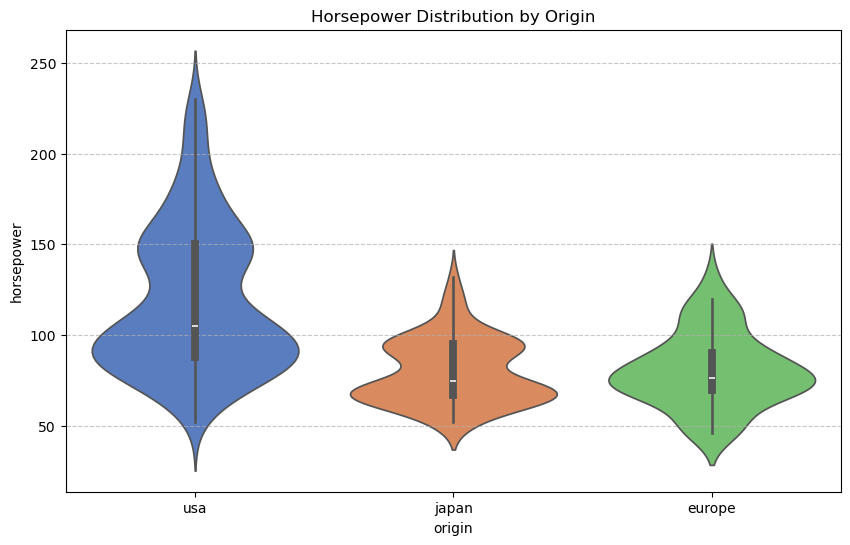

In [6]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=mpg, x='origin', y='horsepower', palette='muted')
plt.title("Horsepower Distribution by Origin")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
# Assumption checks: Shapiro-Wilk + Levene's test

# 1. Normality (Shapiro-Wilk)
print("Shapiro-Wilk Test (Normality):")
for origin in mpg['origin'].unique():
    group_data = mpg[mpg['origin'] == origin]['horsepower']
    stat, p = stats.shapiro(group_data)
    print(f" - {origin}: p-value = {p:.4f}")
    if p >= 0.05:
        print(f"Fail to reject H0: {origin} group is approximately normally distributed.")
    else:
        print(f"Reject H0: {origin} group is not normally distributed.")

# 2. Equal Variance (Levene's Test)
groups = [mpg[mpg['origin'] == o]['horsepower'] for o in mpg['origin'].unique()]
stat_l, p_l = stats.levene(*groups)
print(f"\nLevene's Test (Homogeneity of Variances): p-value = {p_l:.4e}")
if p_l >= 0.05:
    print("Fail to reject H0: Variances are equal across groups.")
else:
    print("Reject H0: Variances are not equal across groups.")

Shapiro-Wilk Test (Normality):
 - usa: p-value = 0.0000
Reject H0: usa group is not normally distributed.
 - japan: p-value = 0.0002
Reject H0: japan group is not normally distributed.
 - europe: p-value = 0.0310
Reject H0: europe group is not normally distributed.

Levene's Test (Homogeneity of Variances): p-value = 1.5863e-11
Reject H0: Variances are not equal across groups.


In [8]:
# One-way ANOVA

# ANOVA
f_stat, p_val = stats.f_oneway(*groups)

# Eta-squared calculation
# SS_between / SS_total
total_mean = mpg['horsepower'].mean()
ss_between = sum(len(g) * (g.mean() - total_mean)**2 for g in groups)
ss_total = sum((mpg['horsepower'] - total_mean)**2)
eta_sq = ss_between / ss_total

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")
print(f"Eta-squared: {eta_sq:.4f}")
if p_val < 0.05:
    print("There is a difference at least in one pair")
else:
    print("There is no difference between paired groups")

print(40 * "-")
print("---- ANOVA RESULTS ----")
anova_results = pg.anova(data=mpg, dv='horsepower', between='origin', detailed=True)
print(anova_results)

F-statistic: 61.3421
p-value: 6.9873e-24
Eta-squared: 0.2398
There is a difference at least in one pair
----------------------------------------
---- ANOVA RESULTS ----
   Source             SS   DF            MS          F         p_unc       np2
0  origin  138894.594943    2  69447.297471  61.342093  6.987301e-24  0.239765
1  Within  440399.037710  389   1132.131202        NaN           NaN       NaN


In [9]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=mpg['horsepower'], groups=mpg['origin'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan  -0.7234 0.9907 -13.8185 12.3717  False
europe    usa  38.4902    0.0  27.6396 49.3407   True
 japan    usa  39.2135    0.0  28.9713 49.4558   True
-----------------------------------------------------


### Interpretation

1. Which groups differ?According to the Tukey HSD (Honestly Significant Difference) table, the groups differ as follows:

    USA vs. Europe & USA vs. Japan: These pairs show a significant difference. The reject column is True, and the adjusted p-values are 0.0. The meandiff shows that USA cars have approximately 38–39 units more horsepower on average than cars from Europe and Japan.

   Europe vs. Japan: There is no significant difference between these two groups. The reject column is False, and the p-value is very high (0.9907). Their mean difference is negligible (-0.72).In short: The USA stands out as a distinct group with significantly higher horsepower, while European and Japanese cars are statistically similar to one another in this metric.

   2. What does the effect size tell you?Your results report an Eta-squared ($\eta^2$) of 0.2398 (or approximately 24%).

    Interpretation: The effect size tells us the "magnitude" of the difference rather than just whether it exists. An $\eta^2$ of 0.24 is considered a large effect.

    Practical Meaning: This means that 24% of the total variation in horsepower can be explained solely by knowing the car's origin.

    Context: While other factors (like the year the car was made or its weight) also play a role, the region of origin is a powerful predictor of how much power the engine has. It reflects the clear historical divergence in manufacturing: the American market's preference for high-power engines versus the fuel-efficiency and compactness priorities in the Japanese and European markets.

   3. A Note on AssumptionsIt is worth noting that your Shapiro-Wilk and Levene’s tests both rejected the null hypothesis (p < 0.05). This indicates that your data technically violates the assumptions of normality and equal variance. However, because your F-statistic is so high (61.34) and the p-value is so low ($6.98 \times 10^{-24}$), the finding of a significant difference remains highly robust despite these violations.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [11]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=SEED, max_iter=1000))
])

# 2. Decision Tree
dt_clf = DecisionTreeClassifier(random_state=SEED)

# Fitting
lr_pipe.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipe.predict(X_test)
y_pred_dt = dt_clf.predict(X_test)

In [12]:
# Classification reports
print("--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, y_pred_dt))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98


--- Decision Tree Report ---
              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [13]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric."""
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y_true))
    boot_scores = []

    for _ in range(n_boot):
        # Resample indices with replacement
        resampled_idx = rng.choice(indices, size=len(indices), replace=True)
        
        # Calculate metric on the resampled data
        # average='macro' is typically used for multi-class targets like origin
        score = metric_fn(y_true[resampled_idx], y_pred[resampled_idx], average='macro')
        boot_scores.append(score)

    boot_scores = np.array(boot_scores)
    
    # Calculate point estimate (mean) and 95% CI (2.5th and 97.5th percentiles)
    point_estimate = np.mean(boot_scores)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores

In [ ]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
metrics_list = [
    ("F1-Score", f1_score),
    ("Precision", precision_score),
    ("Recall", recall_score)
]

models_preds = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt)
]

results = []

for model_name, preds in models_preds:
    for metric_name, metric_fn in metrics_list:
        est, low, high, _ = bootstrap_metric(y_test, preds, metric_fn)
        results.append({
            "Model": model_name,
            "Metric": metric_name,
            "Estimate": est,
            "CI_Lower": low,
            "CI_Upper": high
        })

df_results = pd.DataFrame(results)
print(df_results)

In [ ]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
plt.figure(figsize=(10, 6))

for i, model_name in enumerate(df_results["Model"].unique()):
    subset = df_results[df_results["Model"] == model_name]
    
    # Calculate error bars (difference from mean)
    y_err = [subset["Estimate"] - subset["CI_Lower"], subset["CI_Upper"] - subset["Estimate"]]
    
    # Offset Y-axis slightly to separate the models
    y_pos = np.arange(len(subset)) + (i * 0.2)
    
    plt.errorbar(x=subset["Estimate"], y=y_pos, xerr=y_err, 
                 fmt='o', capsize=5, label=model_name)

plt.yticks(np.arange(len(metrics_list)) + 0.1, [m[0] for m in metrics_list])
plt.xlabel("Metric Score")
plt.title("95% Bootstrap Confidence Intervals by Model")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

I recommend the Decision Tree model for this classification task.

My confidence in this recommendation is high based on the following observations from the bootstrap confidence intervals (CIs):

--- Superior Performance Estimates: The Decision Tree achieves significantly higher point estimates across all key metrics. Specifically, its estimated macro F1-score is 0.828, compared to just 0.716 for the Logistic Regression model.

--- Confidence Interval Separation: There is a clear separation between the models' performance ranges. Most notably, the lower bound of the Decision Tree's F1-score CI (0.730) is higher than the mean estimate of the Logistic Regression model (0.716). This indicates that even in its "worst-case" resampled scenarios, the Decision Tree typically outperforms the average case of the linear model.

--- Metric Consistency: The Decision Tree shows strong and consistent gains in both Precision (0.853) and Recall (0.829) over the Logistic Regression model (0.787 and 0.702, respectively). The recall specifically shows a dramatic improvement, suggesting the Decision Tree is far more effective at correctly identifying vehicles from underrepresented origins like 'japan' and 'europe'.While both models have relatively wide confidence intervals—likely due to the small size of the test set ($n=98$)—the consistent lead maintained by the Decision Tree makes it the statistically superior choice for this dataset.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

   
The correlation analysis identified weight and displacement as having the strongest positive relationship ($r = 0.9330$). These variables also show a powerful inverse correlation with fuel efficiency (mpg); specifically, vehicle weight has a high negative correlation ($r = -0.83$), indicating that as mass increases, fuel economy drops significantly. Furthermore, the higher Spearman coefficient for horsepower vs. mpg ($\rho = -0.8536$) compared to its Pearson value ($r = -0.7784$) suggests a non-linear relationship where efficiency decreases sharply as power increases before eventually leveling off.

   Regional differences are statistically significant, as confirmed by a one-way ANOVA on horsepower ($F = 61.34$, $p < 0.05$). Post-hoc testing revealed that vehicles from the USA stand out with significantly higher horsepower—averaging 38–39 units more—than those from Japan or Europe. The large effect size ($\eta^2 = 0.2398$) indicates that approximately 24% of the variance in horsepower is explained solely by the car's origin.
   
   For classification, I recommend the Decision Tree model. It achieved a macro F1-score of 0.8277, notably outperforming the 0.7157 produced by Logistic Regression. 95% Bootstrap Confidence Intervals provide high certainty for this recommendation, as the Decision Tree’s lower bound for the F1-score (0.7296) is higher than the Logistic Regression’s mean estimate.

### Your Summary

   The exploration of the mpg dataset reveals a clear divide between vehicle specifications and manufacturing regions. The strongest positive correlation exists between weight and displacement ($r = 0.9330$), both of which are primary drivers of reduced fuel efficiency. The non-linear nature of the horsepower vs. mpg relationship is particularly notable, captured more effectively by the Spearman coefficient ($\rho = -0.8536$), which highlights how power gains disproportionately impact fuel economy.
   
   Statistically, car origins differ significantly in terms of engine power. While Japan and Europe produce vehicles with similar horsepower profiles ($p = 0.9907$), USA-made cars are significantly more powerful, reflecting a distinct regional engineering priority for performance over compactness. This origin factor is a potent predictor, accounting for nearly 24% of the observed variance in horsepower.
   
   In terms of predictive modeling, the Decision Tree is the superior classifier. It maintains a macro F1-score of 0.83, a significant lead over Logistic Regression’s 0.72. Bootstrap CI analysis confirms this choice is robust, as the performance range for the Decision Tree stays consistently above the average performance of the linear model, suggesting that regional manufacturing patterns are better identified through non-linear decision boundaries.